# Análise Exploratória de Dados — FakeNewsNet
---
**Projeto:** Sistema Inteligente de Deteção e Mitigação de Desinformação em Redes Sociais
**Aluna:** Diana Dória | UCP — Ciência de Dados Aplicada
**Data:** Março 2026

### Objetivos desta análise:
- Compreender a estrutura e dimensão dos datasets
- Identificar colunas úteis (texto, metadados, labels)
- Verificar distribuição de classes (fake vs real)
- Identificar missing values e problemas de qualidade
- Preparar decisões para o pré-processamento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

BASE_DIR = Path("../data/raw/fakenewsnet")

print("Ficheiros disponíveis:")
for f in sorted(BASE_DIR.glob("*.csv")):
    size_kb = f.stat().st_size / 1024
    print(f"   {f.name:<45} ({size_kb:.1f} KB)")

Ficheiros disponíveis:
   BuzzFeed_fake_news_content.csv                (636.1 KB)
   BuzzFeed_real_news_content.csv                (593.0 KB)
   PolitiFact_fake_news_content.csv              (825.4 KB)
   PolitiFact_real_news_content.csv              (825.4 KB)
   gossipcop_fake.csv                            (12244.8 KB)
   gossipcop_real.csv                            (19509.9 KB)
   politifact_fake.csv                           (3209.4 KB)
   politifact_real.csv                           (8084.6 KB)


## 1. Carregamento dos Dados

In [2]:
file_map = {
    "buzzfeed_fake":      "BuzzFeed_fake_news_content.csv",
    "buzzfeed_real":      "BuzzFeed_real_news_content.csv",
    "politifact_content_fake": "PolitiFact_fake_news_content.csv",
    "politifact_content_real": "PolitiFact_real_news_content.csv",
    "gossipcop_fake":     "gossipcop_fake.csv",
    "gossipcop_real":     "gossipcop_real.csv",
    "politifact_fake":    "politifact_fake.csv",
    "politifact_real":    "politifact_real.csv",
}

datasets = {}

print(f"{'Dataset':<35} {'Linhas':>8} {'Colunas':>9}  Colunas")
print("─" * 90)

for key, fname in file_map.items():
    df = pd.read_csv(BASE_DIR / fname)
    df["label"]  = 1 if "fake" in key else 0   # 1=fake, 0=real
    df["source"] = key
    datasets[key] = df
    print(f"{key:<35} {len(df):>8} {len(df.columns)-2:>9}  {[c for c in df.columns if c not in ['label','source']]}")

Dataset                               Linhas   Colunas  Colunas
──────────────────────────────────────────────────────────────────────────────────────────
buzzfeed_fake                             91        11  ['id', 'title', 'text', 'url', 'top_img', 'authors', 'publish_date', 'movies', 'images', 'canonical_link', 'meta_data']
buzzfeed_real                             91        11  ['id', 'title', 'text', 'url', 'top_img', 'authors', 'publish_date', 'movies', 'images', 'canonical_link', 'meta_data']
politifact_content_fake                  120        11  ['id', 'title', 'text', 'url', 'top_img', 'authors', 'publish_date', 'movies', 'images', 'canonical_link', 'meta_data']
politifact_content_real                  120        11  ['id', 'title', 'text', 'url', 'top_img', 'authors', 'publish_date', 'movies', 'images', 'canonical_link', 'meta_data']
gossipcop_fake                          5323         4  ['id', 'news_url', 'title', 'tweet_ids']
gossipcop_real                         16817

## 2. Visão Geral dos Dados

### Decisão de arquitetura:
- **Ficheiros `*_content.csv`** (BuzzFeed + PolitiFact): têm `title` + `text` completo → usados para o módulo **NLP/BERT**
- **Ficheiros com `tweet_ids`** (GossipCop + PolitiFact): têm dados de propagação → usados para **análise de redes**

In [3]:
print("=" * 55)
print("TIPO 1 — Conteúdo completo (NLP/BERT)")
print("=" * 55)

content_keys = ["buzzfeed_fake", "buzzfeed_real",
                "politifact_content_fake", "politifact_content_real"]

total_content = 0
for key in content_keys:
    df = datasets[key]
    label = "FAKE" if df["label"].iloc[0] == 1 else "REAL"
    print(f"  {key:<35} {len(df):>6} artigos [{label}]")
    total_content += len(df)

fake_c = sum(len(datasets[k]) for k in content_keys if "fake" in k)
real_c = sum(len(datasets[k]) for k in content_keys if "real" in k)
print(f"\n  TOTAL: {total_content} → FAKE: {fake_c} ({fake_c/total_content*100:.1f}%) | REAL: {real_c} ({real_c/total_content*100:.1f}%)")

print()
print("=" * 55)
print("TIPO 2 — Dados de propagação (Redes)")
print("=" * 55)

network_keys = ["gossipcop_fake", "gossipcop_real",
                "politifact_fake", "politifact_real"]

total_network = 0
for key in network_keys:
    df = datasets[key]
    label = "FAKE" if df["label"].iloc[0] == 1 else "REAL"
    print(f"  {key:<35} {len(df):>6} artigos [{label}]")
    total_network += len(df)

fake_n = sum(len(datasets[k]) for k in network_keys if "fake" in k)
real_n = sum(len(datasets[k]) for k in network_keys if "real" in k)
print(f"\n  TOTAL: {total_network} → FAKE: {fake_n} ({fake_n/total_network*100:.1f}%) | REAL: {real_n} ({real_n/total_network*100:.1f}%)")

TIPO 1 — Conteúdo completo (NLP/BERT)
  buzzfeed_fake                           91 artigos [FAKE]
  buzzfeed_real                           91 artigos [REAL]
  politifact_content_fake                120 artigos [FAKE]
  politifact_content_real                120 artigos [REAL]

  TOTAL: 422 → FAKE: 211 (50.0%) | REAL: 211 (50.0%)

TIPO 2 — Dados de propagação (Redes)
  gossipcop_fake                        5323 artigos [FAKE]
  gossipcop_real                       16817 artigos [REAL]
  politifact_fake                        432 artigos [FAKE]
  politifact_real                        624 artigos [REAL]

  TOTAL: 23196 → FAKE: 5755 (24.8%) | REAL: 17441 (75.2%)


## 3. Análise de Qualidade — Missing Values

In [4]:
print("MISSING VALUES — Ficheiros de conteúdo (NLP)\n")

content_keys = ["buzzfeed_fake", "buzzfeed_real",
                "politifact_content_fake", "politifact_content_real"]

for key in content_keys:
    df = datasets[key]
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    pct = (missing / len(df) * 100).round(1)
    print(f"  {key}")
    if missing.empty:
        print("     Sem missing values\n")
    else:
        for col in missing.index:
            print(f"     {col:<20} {missing[col]:>4} em falta ({pct[col]}%)")
        print()

MISSING VALUES — Ficheiros de conteúdo (NLP)

  buzzfeed_fake
     url                     8 em falta (8.8%)
     top_img                10 em falta (11.0%)
     authors                34 em falta (37.4%)
     publish_date           14 em falta (15.4%)
     movies                 70 em falta (76.9%)
     images                 10 em falta (11.0%)
     canonical_link         11 em falta (12.1%)

  buzzfeed_real
     authors                 7 em falta (7.7%)
     publish_date           35 em falta (38.5%)
     movies                 87 em falta (95.6%)
     canonical_link          1 em falta (1.1%)

  politifact_content_fake
     url                     2 em falta (1.7%)
     top_img                 2 em falta (1.7%)
     authors                13 em falta (10.8%)
     publish_date           39 em falta (32.5%)
     movies                113 em falta (94.2%)
     images                  2 em falta (1.7%)
     canonical_link          5 em falta (4.2%)

  politifact_content_real
     url  

In [5]:
print("AMOSTRA DE TEXTOS\n")

df_sample = datasets["buzzfeed_fake"]

for i in range(2):
    print(f"── Exemplo {i+1} [FAKE] ──────────────────────")
    print(f"  TÍTULO : {df_sample['title'].iloc[i]}")
    print(f"  TEXTO  : {str(df_sample['text'].iloc[i])[:300]}...")
    print(f"  AUTORES: {df_sample['authors'].iloc[i]}")
    print(f"  DATA   : {df_sample['publish_date'].iloc[i]}")
    print()

df_sample2 = datasets["buzzfeed_real"]
for i in range(2):
    print(f"── Exemplo {i+1} [REAL] ──────────────────────")
    print(f"  TÍTULO : {df_sample2['title'].iloc[i]}")
    print(f"  TEXTO  : {str(df_sample2['text'].iloc[i])[:300]}...")
    print()

AMOSTRA DE TEXTOS

── Exemplo 1 [FAKE] ──────────────────────
  TÍTULO : Proof The Mainstream Media Is Manipulating The Election By Taking Bill Clinton Out Of Context
  TEXTO  : I woke up this morning to find a variation of this headline splashed all over my news feed:

Bill Clinton: ‘Natural’ For Foundation Donors to Seek Favors

Here’s Google:

Naturally, my reaction was “oh, s**t, what did Bill Clinton do to damage his wife’s campaign now?”

Of course, the headline sound...
  AUTORES: Wendy Gittleson
  DATA   : {'$date': 1474243200000}

── Exemplo 2 [FAKE] ──────────────────────
  TÍTULO : Charity: Clinton Foundation Distributed “Watered-Down” AIDS Drugs to Sub-Saharan Africa – Eagle Rising
  TEXTO  : Former President Bill Clinton and his Clinton Health Access Initiative (CHAI) distributed “watered-down” HIV/AIDs drugs to patients in sub-Saharan Africa, and “likely increased” the risks of morbidity and mortality, according to a draft congressional report obtained by The Daily Caller

## 4. Distribuição das Classes

Dataset NLP combinado: 422 artigos



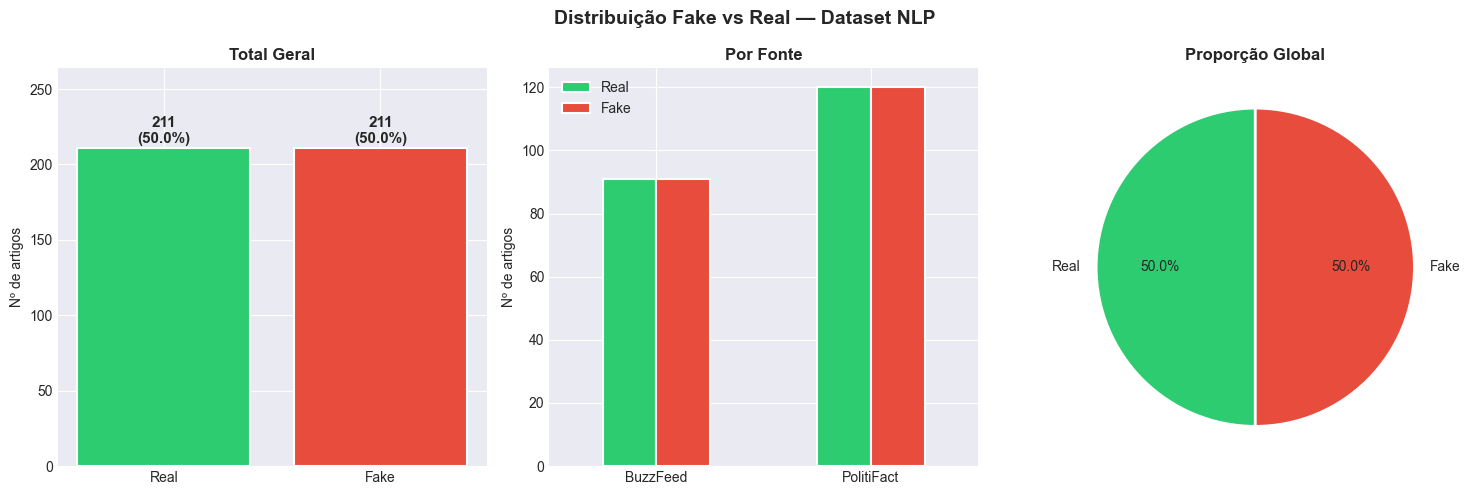

Gráfico guardado em results/figures/


In [6]:
# Combinar só os ficheiros de conteúdo (NLP)
content_keys = ["buzzfeed_fake", "buzzfeed_real",
                "politifact_content_fake", "politifact_content_real"]

df_nlp = pd.concat([datasets[k] for k in content_keys], ignore_index=True)

# Adicionar coluna de source limpa
df_nlp["source_clean"] = df_nlp["source"].apply(
    lambda x: "BuzzFeed" if "buzzfeed" in x else "PolitiFact"
)

print(f"Dataset NLP combinado: {df_nlp.shape[0]} artigos\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Distribuição Fake vs Real — Dataset NLP", fontsize=14, fontweight="bold")

colors = ["#2ecc71", "#e74c3c"]  # verde=real, vermelho=fake

# --- Gráfico 1: total geral ---
counts_total = df_nlp["label"].value_counts().sort_index()
bars = axes[0].bar(["Real", "Fake"], counts_total.values, color=colors,
                   edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, counts_total.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val}\n({val/len(df_nlp)*100:.1f}%)",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_title("Total Geral", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Nº de artigos")
axes[0].set_ylim(0, max(counts_total.values) * 1.25)

# --- Gráfico 2: por source ---
source_label = df_nlp.groupby(["source_clean", "label"]).size().unstack(fill_value=0)
source_label.columns = ["Real", "Fake"]
source_label.plot(kind="bar", ax=axes[1], color=colors,
                  edgecolor="white", linewidth=1.5)
axes[1].set_title("Por Fonte", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Nº de artigos")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend()

# --- Gráfico 3: pie chart ---
axes[2].pie(counts_total.values, labels=["Real", "Fake"],
            colors=colors, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[2].set_title("Proporção Global", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("../results/figures/01_distribuicao_classes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado em results/figures/")

## 5. Comprimento dos Textos

ESTATÍSTICAS DE COMPRIMENTO

── Título (nº palavras) ──
       mean  min   50%   max
label                       
Real   10.4  3.0  10.0  29.0
Fake   11.3  3.0  11.0  29.0

── Texto completo (nº palavras) ──
        mean   min    50%     max
label                            
Real   624.0  31.0  394.0  5459.0
Fake   563.6   5.0  394.0  5292.0


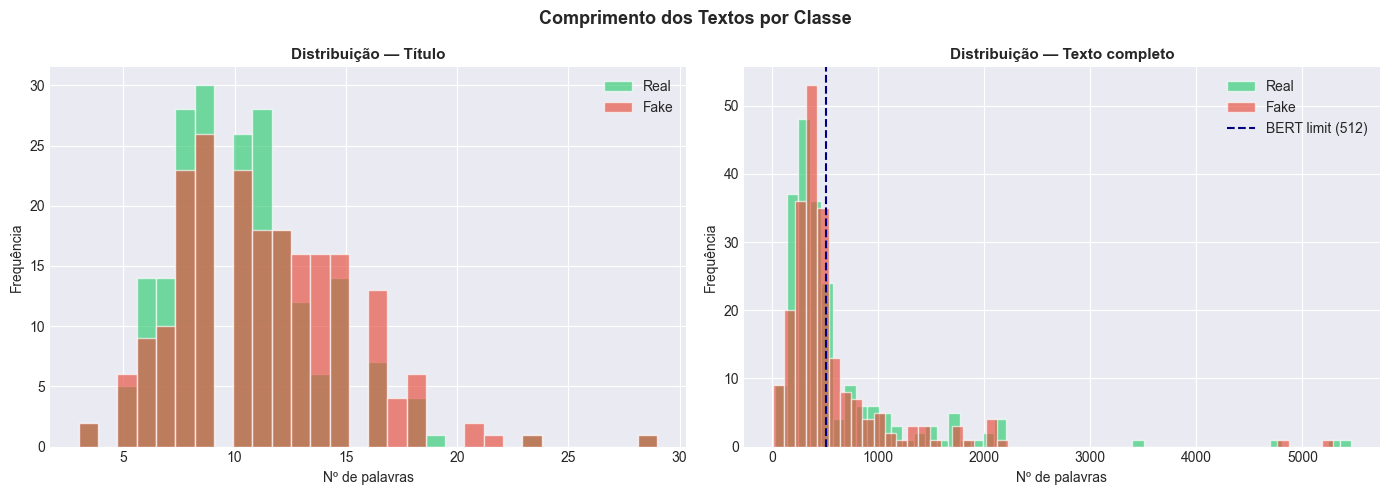


 Textos com mais de 512 palavras (limite BERT): 134 (31.8%)
   → Estes serão truncados automaticamente pelo tokenizer


In [7]:
df_nlp["title_words"] = df_nlp["title"].astype(str).apply(lambda x: len(x.split()))
df_nlp["text_words"]  = df_nlp["text"].astype(str).apply(lambda x: len(x.split()))
df_nlp["text_chars"]  = df_nlp["text"].astype(str).apply(len)

print("ESTATÍSTICAS DE COMPRIMENTO\n")
print("── Título (nº palavras) ──")
print(df_nlp.groupby("label")["title_words"]
      .describe()[["mean","min","50%","max"]]
      .rename(index={0:"Real", 1:"Fake"})
      .round(1).to_string())

print("\n── Texto completo (nº palavras) ──")
print(df_nlp.groupby("label")["text_words"]
      .describe()[["mean","min","50%","max"]]
      .rename(index={0:"Real", 1:"Fake"})
      .round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comprimento dos Textos por Classe", fontsize=13, fontweight="bold")

label_names = {0: "Real", 1: "Fake"}
colors_map  = {0: "#2ecc71", 1: "#e74c3c"}

for label_val in [0, 1]:
    subset = df_nlp[df_nlp["label"] == label_val]
    axes[0].hist(subset["title_words"], bins=30, alpha=0.65,
                 label=label_names[label_val], color=colors_map[label_val])
    axes[1].hist(subset["text_words"],  bins=50, alpha=0.65,
                 label=label_names[label_val], color=colors_map[label_val])

# Linha BERT max tokens
axes[1].axvline(x=512, color="navy", linestyle="--", linewidth=1.5, label="BERT limit (512)")

for ax, title, xlabel in zip(axes,
    ["Distribuição — Título", "Distribuição — Texto completo"],
    ["Nº de palavras", "Nº de palavras"]):
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequência")
    ax.legend()

plt.tight_layout()
plt.savefig("../results/figures/02_comprimento_textos.png", dpi=150, bbox_inches="tight")
plt.show()

# Percentagem de textos que excedem o limite do BERT
over_512 = (df_nlp["text_words"] > 512).sum()
print(f"\n Textos com mais de 512 palavras (limite BERT): {over_512} ({over_512/len(df_nlp)*100:.1f}%)")
print("   → Estes serão truncados automaticamente pelo tokenizer")

## 6. Decisões para o Pré-processamento

| # | Decisão | Justificação |
|---|---------|--------------|
| 1 | **Dataset NLP principal:** BuzzFeed + PolitiFact content | Únicos com `text` completo |
| 2 | **Input BERT:** `title + [SEP] + text` | Captura título e corpo do artigo |
| 3 | **Truncação:** 512 tokens (automática) | 31.8% dos textos excedem o limite — comportamento esperado |
| 4 | **Balanceamento:** nenhuma ação necessária | Dataset perfeitamente 50/50 |
| 5 | **Colunas a descartar:** `top_img`, `movies`, `images`, `canonical_link`, `meta_data` | Irrelevantes para NLP |
| 6 | **`publish_date`:** converter de timestamp Unix | Formato `{'$date': ...}` — tratar no pré-processamento |
| 7 | **Dataset de redes:** GossipCop + PolitiFact (tweet_ids) | Para módulo de análise de redes (fase seguinte) |

## 7. Resumo Final da EDA

In [8]:
print("=" * 60)
print("RESUMO FINAL DA EDA — FakeNewsNet")
print("=" * 60)

print("""
𑣲DATASETS DISPONÍVEIS
─────────────────────────────────────────
  Tipo 1 — Conteúdo (NLP/BERT):
    • BuzzFeed:    91 fake + 91 real  =  182 artigos
    • PolitiFact: 120 fake + 120 real =  240 artigos
    • TOTAL:      422 artigos | 50% fake | 50% real

  Tipo 2 — Propagação (Redes):
    • GossipCop:   5323 fake + 16817 real = 22140 artigos
    • PolitiFact:   432 fake +   624 real =  1056 artigos
    • TOTAL:      23196 artigos | 24.8% fake | 75.2% real
""")

print("""QUALIDADE DO TEXTO
─────────────────────────────────────────
  • Colunas 'title' e 'text': sem missing values
  • Comprimento médio título:  ~11 palavras
  • Comprimento médio texto:  ~594 palavras
  • Textos > 512 tokens:       31.8% (truncação automática pelo BERT)
""")

print("""PRÓXIMO PASSO: Pré-processamento
─────────────────────────────────────────
  1. Limpar texto (URLs, emojis, caracteres especiais)
  2. Converter publish_date de timestamp Unix
  3. Criar coluna 'input_text' = title + [SEP] + text
  4. Criar splits train / val / test (80 / 10 / 10)
  5. Guardar train.csv, val.csv, test.csv em data/processed/
""")
print("=" * 60)

RESUMO FINAL DA EDA — FakeNewsNet

𑣲DATASETS DISPONÍVEIS
─────────────────────────────────────────
  Tipo 1 — Conteúdo (NLP/BERT):
    • BuzzFeed:    91 fake + 91 real  =  182 artigos
    • PolitiFact: 120 fake + 120 real =  240 artigos
    • TOTAL:      422 artigos | 50% fake | 50% real

  Tipo 2 — Propagação (Redes):
    • GossipCop:   5323 fake + 16817 real = 22140 artigos
    • PolitiFact:   432 fake +   624 real =  1056 artigos
    • TOTAL:      23196 artigos | 24.8% fake | 75.2% real 

QUALIDADE DO TEXTO
─────────────────────────────────────────
  • Colunas 'title' e 'text': sem missing values
  • Comprimento médio título:  ~11 palavras
  • Comprimento médio texto:  ~594 palavras
  • Textos > 512 tokens:       31.8% (truncação automática pelo BERT)

PRÓXIMO PASSO: Pré-processamento
─────────────────────────────────────────
  1. Limpar texto (URLs, emojis, caracteres especiais)
  2. Converter publish_date de timestamp Unix
  3. Criar coluna 'input_text' = title + [SEP] + text
  4.